<a href="https://colab.research.google.com/github/esthy13/BasketBall_ScoreBoard/blob/main/0_dimensions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Less is more? - Assignment

#### ⏰ Deadline: Wednesday, April 29, 20:00
### What is this notebook about?

In the paper "The curse(s) of dimensionality, the authors note “We generally think that more information is better than less. However, in the ‘big data’ era, the sheer number of variables that can be collected from a single sample can be problematic. This embarrassment of riches is called the ‘curse of dimensionality’ (CoD).”

You have most likely already heard about the curse of dimensionality and will also encounter the term in the seminar papers. The following three stations in this notebook will guide you to  refresh and contextualize your understanding.

---

---

#### 🟢 Station 1: Exploring distance in higher dimensions

We live in a 3D world (ignoring time), where objects can be positioned left-right, forward-backward, up and down. Now imagine a world where you would need to describe objects not in 3 but in 10, 50 even 1000 coordinates. It's hard to imagine because our intuitions are  made for a 3D world, so let's find out by simulation!

##### 🎯Your goal: find out how distances between data points behave in different dimensions and using different distance metrics.

🧭 Here are some points to guide you:
- Create datasets X of shape (N,D) with N=100 data points and varying dimensions D∈{100,300,500,700,900,1000}. Draw the values for each dimension independently from a Gaussian distribution.
- Visualize how pairwise distances behave when the dimensions increase. What happens to the separation between the closest and farthest points?
- Try out different distance metrics (e.g. Euclidean, cosine). How does the choice of distance metric affect the results?
  
🔍 What would dimensions correspond to for a dataset? What implications do your findings have for machine learning?

In [20]:
import numpy as np
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

N = 100
D_values = [100, 300, 500, 700, 900, 1000]

# Define metrics in one place
metrics = {
    "Euclidean": ("euclidean", {}),
    "Chebyshev": ("chebyshev", {}),
    "Minkowski (p=2)": ("minkowski", {"p": 2.0}),
    "Cosine": ("cosine", {}),
}

# Store results for plotting
results1 = {name: [] for name in metrics}

def analyze_distances(X, metric, **kwargs):
    pair_dist = pdist(X, metric=metric, **kwargs)
    return pair_dist.min(), pair_dist.max(), pair_dist.min() / pair_dist.max()

for d in D_values:
    X = np.random.normal(0, 0.1, (N, d))
    print(f"\nD = {d}, shape = {X.shape}")

    for name, (metric, params) in metrics.items():
        d_min, d_max, ratio = analyze_distances(X, metric, **params)
        results1[name].append(ratio)

        print(f"{name}: min={d_min:.4f}, max={d_max:.4f}, min/max={ratio:.4f}")


D = 100, shape = (100, 100)
Euclidean: min=0.9845, max=1.7620, min/max=0.5587
Chebyshev: min=0.2348, max=0.6552, min/max=0.3584
Minkowski (p=2): min=0.9845, max=1.7620, min/max=0.5587
Cosine: min=0.6537, max=1.3638, min/max=0.4793

D = 300, shape = (100, 300)
Euclidean: min=2.0910, max=2.8356, min/max=0.7374
Chebyshev: min=0.3145, max=0.6822, min/max=0.4610
Minkowski (p=2): min=2.0910, max=2.8356, min/max=0.7374
Cosine: min=0.7936, max=1.1949, min/max=0.6642

D = 500, shape = (100, 500)
Euclidean: min=2.8176, max=3.5930, min/max=0.7842
Chebyshev: min=0.3157, max=0.7005, min/max=0.4506
Minkowski (p=2): min=2.8176, max=3.5930, min/max=0.7842
Cosine: min=0.8235, max=1.1993, min/max=0.6867

D = 700, shape = (100, 700)
Euclidean: min=3.3297, max=4.0930, min/max=0.8135
Chebyshev: min=0.3411, max=0.7099, min/max=0.4805
Minkowski (p=2): min=3.3297, max=4.0930, min/max=0.8135
Cosine: min=0.8409, max=1.1639, min/max=0.7225

D = 900, shape = (100, 900)
Euclidean: min=3.8723, max=4.6091, min/max=

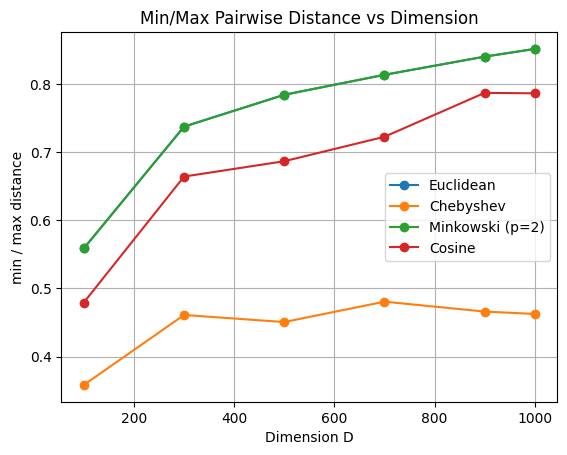

In [21]:
# Plot results
for name, values in results1.items():
    plt.plot(D_values, values, marker='o', label=name)

plt.xlabel("Dimension D")
plt.ylabel("min / max distance")
plt.title("Min/Max Pairwise Distance vs Dimension") # also called distance concentration
plt.legend()
plt.grid(True)
plt.show()

---

#### 🟢🟢 Station 2: Distinguishing classes in higher dimensions

In Station 1, you sampled data from a single distrubution. However, in real-world scenarios, data often comes from different sources, such as distinct classes. This raises the question: do high-dimensional distance effects still pose a problem when distributions are separated?

- In addition to the data from station 1, simulate a second set of data points (representing another class) by sampling from another normal distribution. Simulate different degrees of overlap (low, medium and high) between the two distributions.
- Visualize the pairwise distances between data points
   - from the same distribution
   - from the other distribution

🔍 What do you observe as the dimensionality increases? How do your observations depend on the degree of overlap? How does the choice of distance metric affect the results?


=== HIGH OVERLAP (shift=0.1) ===

D = 100
Euclidean: A=0.5898, B=0.6268, between=0.5986
Chebyshev: A=0.3469, B=0.3999, between=0.3688
Minkowski (p=2): A=0.5898, B=0.6268, between=0.5986
Cosine: A=0.4717, B=0.3769, between=0.4087

D = 300
Euclidean: A=0.7200, B=0.7512, between=0.7673
Chebyshev: A=0.4192, B=0.4192, between=0.4450
Minkowski (p=2): A=0.7200, B=0.7512, between=0.7673
Cosine: A=0.6550, B=0.5584, between=0.6703

D = 500
Euclidean: A=0.7876, B=0.7976, between=0.8089
Chebyshev: A=0.4893, B=0.4557, between=0.4848
Minkowski (p=2): A=0.7876, B=0.7976, between=0.8089
Cosine: A=0.7091, B=0.6555, between=0.7378

D = 700
Euclidean: A=0.8064, B=0.8274, between=0.8278
Chebyshev: A=0.4704, B=0.5019, between=0.4990
Minkowski (p=2): A=0.8064, B=0.8274, between=0.8278
Cosine: A=0.7711, B=0.7131, between=0.7550

D = 900
Euclidean: A=0.8371, B=0.8502, between=0.8582
Chebyshev: A=0.5166, B=0.4742, between=0.5230
Minkowski (p=2): A=0.8371, B=0.8502, between=0.8582
Cosine: A=0.7776, B=0.7463, b

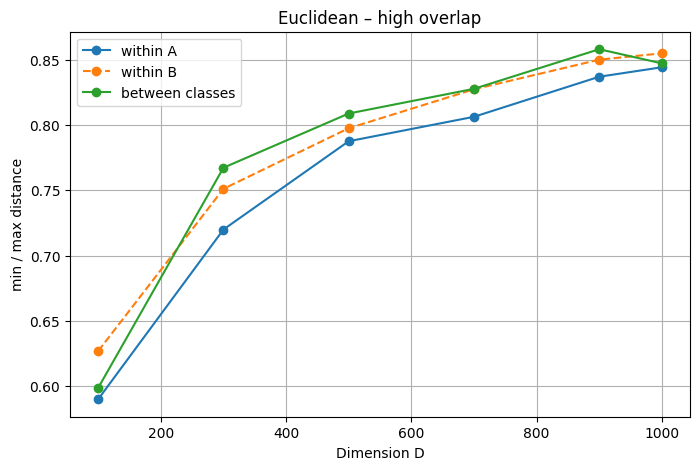

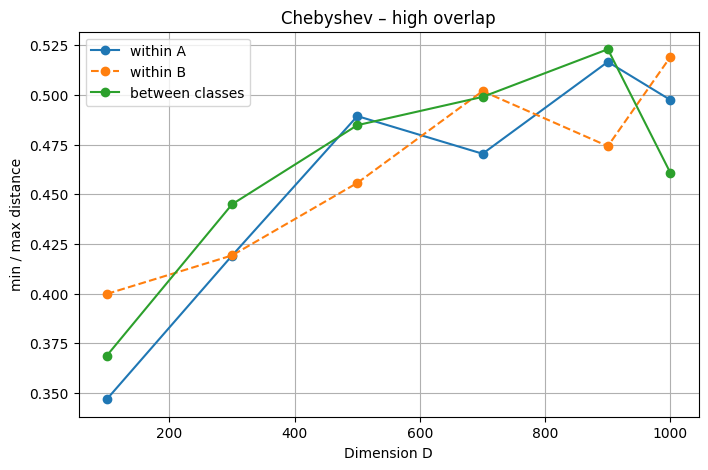

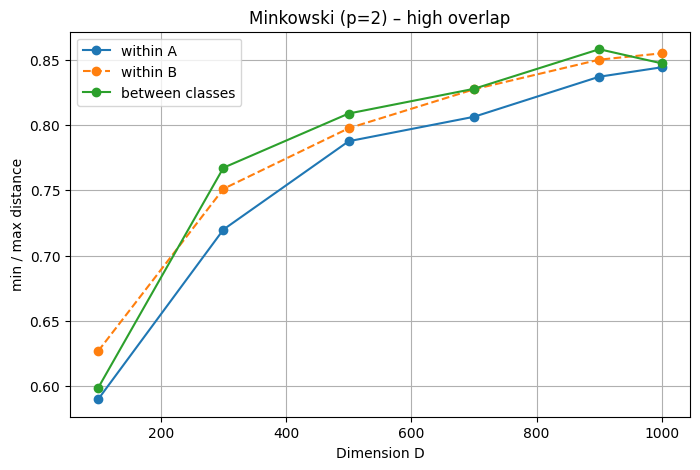

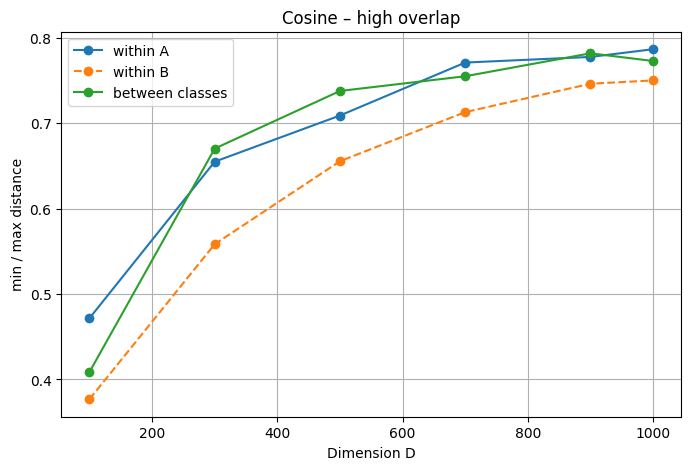


=== MEDIUM OVERLAP (shift=1.0) ===

D = 100
Euclidean: A=0.5849, B=0.5609, between=0.8976
Chebyshev: A=0.3415, B=0.3181, between=0.7119
Minkowski (p=2): A=0.5849, B=0.5609, between=0.8976
Cosine: A=0.4680, B=0.3267, between=0.5292

D = 300
Euclidean: A=0.7333, B=0.7451, between=0.9480
Chebyshev: A=0.4005, B=0.4270, between=0.7623
Minkowski (p=2): A=0.7333, B=0.7451, between=0.9480
Cosine: A=0.6455, B=0.5542, between=0.7511

D = 500
Euclidean: A=0.7761, B=0.8129, between=0.9564
Chebyshev: A=0.4859, B=0.4434, between=0.7608
Minkowski (p=2): A=0.7761, B=0.8129, between=0.9564
Cosine: A=0.7149, B=0.6621, between=0.7595

D = 700
Euclidean: A=0.8385, B=0.8159, between=0.9596
Chebyshev: A=0.4800, B=0.4491, between=0.7535
Minkowski (p=2): A=0.8385, B=0.8159, between=0.9596
Cosine: A=0.7684, B=0.6711, between=0.8215

D = 900
Euclidean: A=0.8453, B=0.8378, between=0.9689
Chebyshev: A=0.4983, B=0.5019, between=0.7581
Minkowski (p=2): A=0.8453, B=0.8378, between=0.9689
Cosine: A=0.7802, B=0.7069,

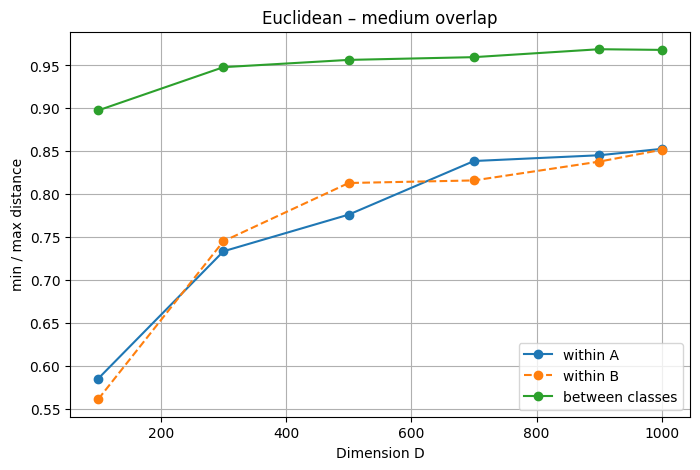

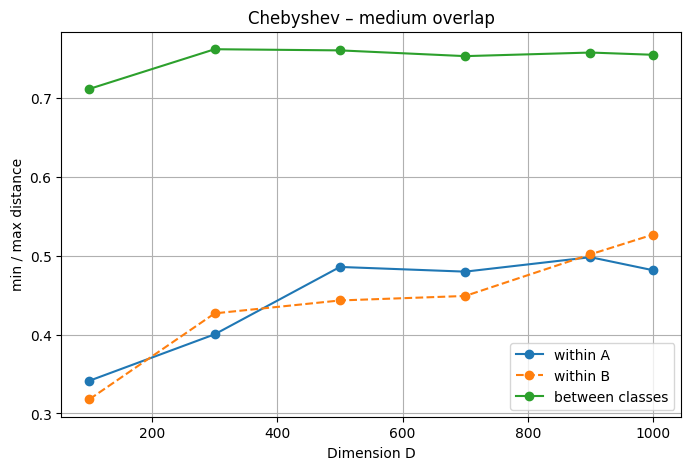

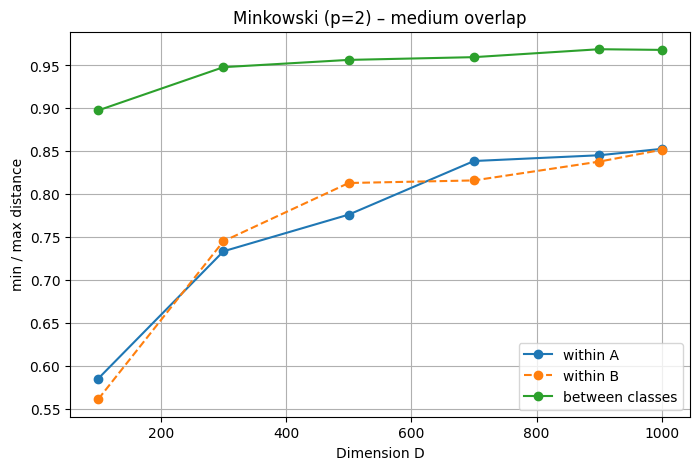

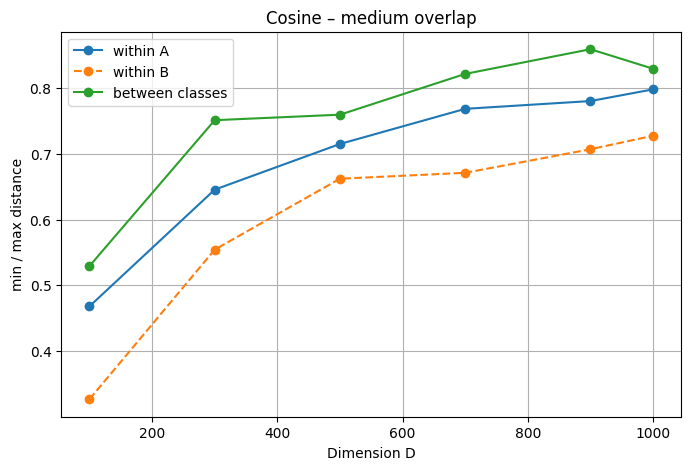


=== LOW OVERLAP (shift=3.0) ===

D = 100
Euclidean: A=0.6012, B=0.6037, between=0.9663
Chebyshev: A=0.3609, B=0.3638, between=0.8686
Minkowski (p=2): A=0.6012, B=0.6037, between=0.9663
Cosine: A=0.4785, B=0.3675, between=0.5457

D = 300
Euclidean: A=0.7342, B=0.7257, between=0.9819
Chebyshev: A=0.4397, B=0.4396, between=0.8834
Minkowski (p=2): A=0.7342, B=0.7257, between=0.9819
Cosine: A=0.6730, B=0.5268, between=0.7639

D = 500
Euclidean: A=0.8106, B=0.7991, between=0.9846
Chebyshev: A=0.4660, B=0.4698, between=0.8739
Minkowski (p=2): A=0.8106, B=0.7991, between=0.9846
Cosine: A=0.7165, B=0.6345, between=0.7841

D = 700
Euclidean: A=0.8000, B=0.8236, between=0.9875
Chebyshev: A=0.5002, B=0.4623, between=0.8767
Minkowski (p=2): A=0.8000, B=0.8236, between=0.9875
Cosine: A=0.7810, B=0.6813, between=0.8271

D = 900
Euclidean: A=0.8597, B=0.8308, between=0.9894
Chebyshev: A=0.5126, B=0.4842, between=0.8952
Minkowski (p=2): A=0.8597, B=0.8308, between=0.9894
Cosine: A=0.7929, B=0.6915, be

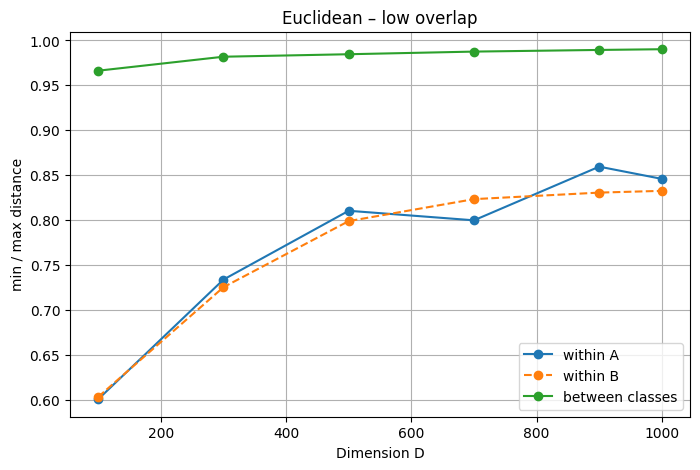

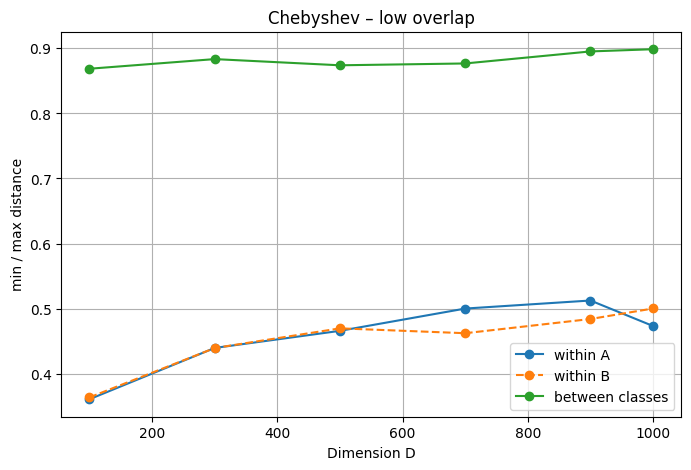

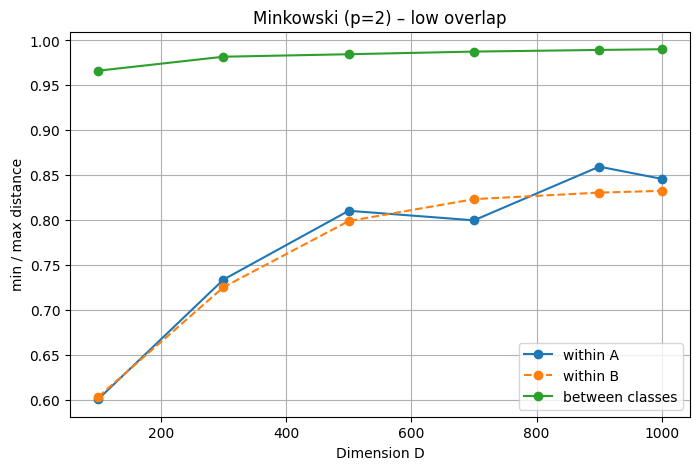

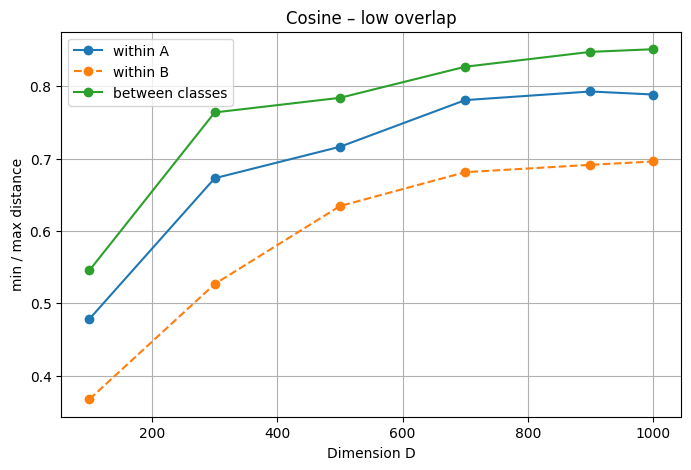

In [22]:
import numpy as np
from scipy.spatial.distance import pdist, cdist
import matplotlib.pyplot as plt

# Control overlap via mean shift
overlap = {
    "high overlap": 0.1,
    "medium overlap": 1.0,
    "low overlap": 3.0,
}

def analyze_cross_distances(X1, X2, metric, **kwargs): # distance between data points of distribution A and B
    pair_dist = cdist(X1, X2, metric=metric, **kwargs)
    return pair_dist.min(), pair_dist.max(), pair_dist.min() / pair_dist.max()

for overlap_name, shift in overlap.items():
    print(f"\n=== {overlap_name.upper()} (shift={shift}) ===")

    # store results separately per overlap case
    results2 = {name: {"within_A": [], "within_B": [], "between": []} for name in metrics}

    for d in D_values:
        # Class A
        X1 = np.random.normal(0, 0.1, (N, d))
        # Class B (shifted mean)
        X2 = np.random.normal(shift, 0.1, (N, d))

        print(f"\nD = {d}")

        for name, (metric, params) in metrics.items():
            # within-class
            _, _, r_A = analyze_distances(X1, metric, **params)
            _, _, r_B = analyze_distances(X2, metric, **params)

            # between-class
            _, _, r_between = analyze_cross_distances(X1, X2, metric, **params)

            results2[name]["within_A"].append(r_A)
            results2[name]["within_B"].append(r_B)
            results2[name]["between"].append(r_between)

            print(f"{name}: A={r_A:.4f}, B={r_B:.4f}, between={r_between:.4f}")

    # ---- Plotting ----
    for name in metrics:
        plt.figure(figsize=(8, 5))
        plt.plot(D_values, results2[name]["within_A"], marker='o', label="within A")
        plt.plot(D_values, results2[name]["within_B"], marker='o', linestyle='--', label="within B")
        plt.plot(D_values, results2[name]["between"], marker='o', label="between classes")

        plt.xlabel("Dimension D")
        plt.ylabel("min / max distance")
        plt.title(f"{name} – {overlap_name}")
        plt.legend()
        plt.grid(True)
        plt.show()

---

#### 🟢🟢🟢 Station 3: Hypothetical scenario in a clinical application

##### Collecting new data is often time- and cost-intensive. So let's entertain an alternative: instead of gathering more samples, can we get more information from the sample we already have?

Let's consider a hypothetical scenario in a clinical application.

Imagine we have data on a number of patients: their lab tests, records from their previous check-ups, measurements collected during routine tests. Our data collection process is going well and we are getting more and more information from each patient. Our goal is to use this data to predict a clinical outcome (e.g., a disease severity score).  But there is a twist (that you wouldn't know in real life): among all the data variables, there is only one variable that is actually related to the clinical outcome (e.g. disease severity score).

##### 🎯Your goal: to simulate the described scenario.
🧭 Here are some points to guide you:

- Generate a dataset with a fixed number of patients (N=100) and vary the number of recorded variables F∈{10,50,100,150,200}. Draw the variables independently from a normal distribution.

- Generate ground truth (clinical outcome): Assume that only one variable actually influences the clinical outcome (e.g. disease severity score). Select one variable (e.g. first feature) and use it to generate the target variable (👀hint:think of a simple linear relationship).

- Train and inspect your model: For each dataset with F features, train a linear regression model, extract the learned coefficients for different features and visualize them.

🔍 Describe what you see. How do the coefficients change when we add more features?

---


In [ ]:
# Your code

---

### 🐘 Optional Bonus Station (It's fun)

Have you heard of von Neumann's elephant? Here is the story (from wikipedia):

"In a 2004 article in the journal Nature, Freeman Dyson recounts his meeting with Fermi in 1953. Fermi, while discussing a novel theory Dyson was proposing, offered the harsh critique, "There are two ways of doing calculations in theoretical physics. One way ... is to have a clear physical picture of the process that you are calculating. The other way is to have a precise and self-consistent mathematical formalism. You have neither." Dyson countered by stating that his theory matched Fermi's own data. Fermi asked about a number of arbitrary parameters Dyson used and, upon learning that there were four of them, quoted his friend von Neumann,

"With four parameters I can fit an elephant, and with five I can make him wiggle his trunk.""


If you're up for a challenge - try to fit a model to the elephant in the (class)room (check out the file in here: https://mbp-lab.github.io/sose26-real-world-problems-ai/build/elephant_points-c64c45cc10d2283d7ba880391307260b.csv)!

Think about what it tells about model flexibility and overfitting!

![Elephant](https://github.com/esthy13/BasketBall_ScoreBoard/blob/images/elephant.png?raw=1)

### 📌 **Note:**  Before submitting your notebook on Moodle (https://moodle.uni-bielefeld.de/mod/assign/view.php?id=817607), make sure you have run all the cells and the outputs are showing or submit a pdf with your output!